In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT_DIR / "results"

# Sized for a single-column-width figure in a 2-column ACM sigplan layout
# (~3.3in wide once placed in the paper) -- larger than matplotlib defaults
# so labels stay legible after that much shrinking. No title sizing needed
# since every title call is removed below, not just hidden.
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
})

def silent_mismatch_rate(g):
    return ((~g["keys_match"].astype(bool)) & (g["verification_passed"] == True)).mean()

# --- Load every dataset once, up front ---
toeplitz = pd.read_csv(RESULTS / "sdc_realchannel_toeplitz_allkeys_asymptotic.csv")
final_key = pd.read_csv(RESULTS / "sdc_realchannel_finalkey_allkeys_asymptotic.csv")
reconciliation = pd.read_csv(RESULTS / "reconciliation_clean.csv")
mock = pd.read_csv(RESULTS / "mock_clean.csv")
mock_asym = mock[mock["length_mode"] == "asymptotic"]
synthetic_df = pd.read_csv(RESULTS / "synthetic_qber_sweep.csv")

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
predictors = [
    (toeplitz, lambda p, ell, t: p * (ell / (ell + t)) * 0.5),
    (final_key, lambda p, ell, t: p * (ell / (ell + t))),
]
for ax, (df, predictor) in zip(axes, predictors):
    probs = sorted(df["prob"].unique())
    obs, pred = [], []
    for p in probs:
        sub = df[df["prob"] == p]
        obs.append(silent_mismatch_rate(sub))
        pred.append(sub.apply(lambda r: predictor(p, r["secure_key_length"], r["t_verify"]), axis=1).mean())
    ax.plot(probs, obs, "o-", label="observed")
    ax.plot(probs, pred, "s--", label="predicted")
    ax.set_xscale("log")
    ax.set_xlabel("firing probability")
    ax.set_ylabel("silent mismatch rate")
    ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_model_fit.png"), dpi=150, bbox_inches="tight")
plt.close()

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
probs = sorted(toeplitz["prob"].unique())
obs = [silent_mismatch_rate(toeplitz[toeplitz["prob"] == p]) for p in probs]
naive = probs
proposed = [toeplitz[toeplitz["prob"] == p].apply(
    lambda r: p * (r["secure_key_length"] / (r["secure_key_length"] + r["t_verify"])) * 0.5, axis=1
).mean() for p in probs]
ax.plot(probs, obs, "o-", label="observed")
ax.plot(probs, naive, ":", label="naive (P=p_f)")
ax.plot(probs, proposed, "s--", label="proposed model")
ax.set_xscale("log")
ax.set_xlabel("firing probability")
ax.set_ylabel("mismatch rate")
ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_naive_vs_proposed.png"), dpi=150, bbox_inches="tight")
plt.close()

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
probs = sorted(reconciliation["prob"].unique())
obs = [(~reconciliation[reconciliation["prob"] == p]["keys_match"].astype(bool)).mean() for p in probs]
naive = probs
proposed = [1 - (1 - p) ** reconciliation[reconciliation["prob"] == p]["total_corrections"].mean() for p in probs]
ax.plot(probs, obs, "o-", label="observed")
ax.plot(probs, naive, ":", label="naive (P=p_f)")
ax.plot(probs, proposed, "s--", label="proposed model")
ax.set_xscale("log")
ax.set_xlabel("firing probability")
ax.set_ylabel("mismatch rate")
ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_naive_vs_proposed_recon.png"), dpi=150, bbox_inches="tight")
plt.close()

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].bar(["Redundant PA", "TMR"], [1.0, 0.0])
axes[0].set_ylabel("detection/correction rate")
axes[1].bar(["Redundant PA", "TMR"], [1.08, 2.69])
axes[1].set_ylabel("overhead (x)")
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_redundancy.png"), dpi=150, bbox_inches="tight")
plt.close()

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (df, fault_type) in zip(axes, [(toeplitz, "toeplitz"), (final_key, "final_key")]):
    probs = sorted(df["prob"].unique())
    real_rates = [silent_mismatch_rate(df[df["prob"] == p]) for p in probs]
    mock_sub = mock_asym[mock_asym["fault_type"] == fault_type]
    mock_rates = [silent_mismatch_rate(mock_sub[mock_sub["prob"] == p]) for p in probs]
    ax.plot(probs, real_rates, "o-", label="real channel")
    ax.plot(probs, mock_rates, "s--", label="mock")
    ax.set_xscale("log")
    ax.set_xlabel("firing probability")
    ax.set_ylabel("silent mismatch rate")
    ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_mock_vs_real.png"), dpi=150, bbox_inches="tight")
plt.close()

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
probs = sorted(reconciliation["prob"].unique())
residuals = []
for p in probs:
    sub = reconciliation[reconciliation["prob"] == p]
    obs = (~sub["keys_match"].astype(bool)).mean()
    pool = sub["total_corrections"].mean()
    residuals.append(obs - (1 - (1 - p) ** pool))
ax.axhline(0, color="gray", linestyle=":")
ax.plot(probs, residuals, "o-")
ax.set_xscale("log")
ax.set_xlabel("firing probability")
ax.set_ylabel("observed - predicted")
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_recon_residual.png"), dpi=150, bbox_inches="tight")
plt.close()

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
fault_types = [("Toeplitz", toeplitz), ("Final-key", final_key), ("Reconciliation", reconciliation)]

for row_idx, (name, df) in enumerate(fault_types):
    by_prob = df.groupby("prob").apply(silent_mismatch_rate)
    by_key = df.groupby("key_index").apply(
        lambda g: pd.Series({"qber": g["qber"].iloc[0], "silent_rate": silent_mismatch_rate(g)})
    ).sort_values("qber")

    # Same y-axis scale between the probability column and the QBER column,
    # for THIS fault type -- computed from both columns' actual data so
    # neither one gets clipped or misleadingly zoomed relative to the other.
    row_min = min(by_prob.values.min(), by_key["silent_rate"].values.min())
    row_max = max(by_prob.values.max(), by_key["silent_rate"].values.max())
    pad = (row_max - row_min) * 0.1 if row_max > row_min else 0.05
    y_lo, y_hi = max(0, row_min - pad), min(1, row_max + pad)

    ax_left = axes[row_idx, 0]
    ax_left.plot(by_prob.index, by_prob.values, "o-")
    ax_left.set_xscale("log")
    ax_left.set_xlabel("firing probability")
    ax_left.set_ylabel("silent mismatch rate")
    ax_left.set_ylim(y_lo, y_hi)

    ax_right = axes[row_idx, 1]
    ax_right.plot(by_key["qber"], by_key["silent_rate"], "o-", color="darkorange")
    ax_right.set_xlabel("QBER")
    ax_right.set_ylabel("silent mismatch rate")
    ax_right.set_ylim(y_lo, y_hi)

plt.tight_layout()
plt.savefig(str(RESULTS / "fig_mismatch_prob_and_qber_all_faults.png"), dpi=150, bbox_inches="tight")
plt.close()

In [9]:
per_qber = synthetic_df.groupby("true_qber").apply(lambda g: (~g["keys_match"].astype(bool)).mean())
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(per_qber.index, per_qber.values, "o-", color="darkorange")
ax.set_xlabel("QBER")
ax.set_ylabel("mismatch rate")
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_synthetic_qber_sweep.png"), dpi=150, bbox_inches="tight")
plt.close()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT_DIR / "results"

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,
    "lines.markersize": 10,
})

def silent_mismatch_rate(g):
    return ((~g["keys_match"].astype(bool)) & (g["verification_passed"] == True)).mean()

toeplitz = pd.read_csv(RESULTS / "sdc_realchannel_toeplitz_allkeys_asymptotic.csv")
final_key = pd.read_csv(RESULTS / "sdc_realchannel_finalkey_allkeys_asymptotic.csv")
reconciliation = pd.read_csv(RESULTS / "reconciliation_clean.csv")

MISMATCH_COLOR = "tab:blue"
QBER_COLOR = "tab:red"

fig, axes = plt.subplots(3, 1, figsize=(9, 16))
row_labels = ["a) Toeplitz-matrix fault", "b) Final-key fault", "c) Reconciliation-state fault"]
fault_data = [toeplitz, final_key, reconciliation]

for ax_left, df, label in zip(axes, fault_data, row_labels):
    probs = sorted(df["prob"].unique())

    mismatch_by_prob = [silent_mismatch_rate(df[df["prob"] == p]) for p in probs]
    qber_by_prob = [df[df["prob"] == p]["qber"].mean() for p in probs]  # flat by construction

    ax_left.plot(probs, mismatch_by_prob, "o-", color=MISMATCH_COLOR, label="silent mismatch rate")
    ax_left.set_xscale("log")
    ax_left.set_xlabel("firing probability")
    ax_left.set_ylabel("silent mismatch rate", color=MISMATCH_COLOR)
    ax_left.tick_params(axis="y", labelcolor=MISMATCH_COLOR)

    ax_right = ax_left.twinx()
    ax_right.plot(probs, qber_by_prob, "s--", color=QBER_COLOR, label="QBER")
    ax_right.set_ylabel("QBER", color=QBER_COLOR)
    ax_right.tick_params(axis="y", labelcolor=QBER_COLOR)
    ax_right.set_ylim(0, 0.11)  # keeps QBER visually anchored near the 11% abort threshold for scale context

    # Row label centered below this subplot
    pos = ax_left.get_position()
    fig.text((pos.x0 + pos.x1) / 2, pos.y0 - 0.02, label, ha="center", fontsize=22, fontweight="bold")

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig(str(RESULTS / "fig_mismatch_prob_and_qber_all_faults.png"), dpi=150, bbox_inches="tight")
plt.close()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT_DIR / "results"

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,
    "lines.markersize": 10,
})

def silent_mismatch_rate(g):
    return ((~g["keys_match"].astype(bool)) & (g["verification_passed"] == True)).mean()

toeplitz = pd.read_csv(RESULTS / "sdc_realchannel_toeplitz_allkeys_asymptotic.csv")
final_key = pd.read_csv(RESULTS / "sdc_realchannel_finalkey_allkeys_asymptotic.csv")
reconciliation = pd.read_csv(RESULTS / "reconciliation_clean.csv")

MISMATCH_COLOR = "tab:blue"
QBER_COLOR = "tab:red"
MISMATCH_YLIM = (0, 0.5)  # consistent across all three rows

fig, axes = plt.subplots(3, 1, figsize=(9, 17))
row_labels = ["a) Toeplitz-matrix fault", "b) Final-key fault", "c) Reconciliation-state fault"]
fault_data = [toeplitz, final_key, reconciliation]

for ax_left, df, label in zip(axes, fault_data, row_labels):
    probs = sorted(df["prob"].unique())

    mismatch_by_prob = [silent_mismatch_rate(df[df["prob"] == p]) for p in probs]
    qber_by_prob = [df[df["prob"] == p]["qber"].mean() for p in probs]

    ax_left.plot(probs, mismatch_by_prob, "o-", color=MISMATCH_COLOR, label="silent mismatch rate")
    ax_left.set_xscale("log")
    ax_left.set_xlabel("firing probability")
    ax_left.set_ylabel("silent mismatch rate", color=MISMATCH_COLOR)
    ax_left.tick_params(axis="y", labelcolor=MISMATCH_COLOR)
    ax_left.set_ylim(*MISMATCH_YLIM)

    ax_right = ax_left.twinx()
    ax_right.plot(probs, qber_by_prob, "s--", color=QBER_COLOR, label="QBER")
    ax_right.set_ylabel("QBER", color=QBER_COLOR)
    ax_right.tick_params(axis="y", labelcolor=QBER_COLOR)
    ax_right.set_ylim(0, 0.11)

    # Anchored to this axes' OWN coordinate system (0-1 fraction of its own
    # width/height), not a figure-level position -- this stays correct
    # regardless of what tight_layout/subplots_adjust does afterward, since
    # it moves WITH the axes rather than being computed once beforehand.
    ax_left.text(0.5, -0.38, label, transform=ax_left.transAxes,
                 ha="center", va="top", fontsize=22, fontweight="bold")

# Generous vertical gap so each row's label has clear space below its
# x-axis and above the next row's title -- set BEFORE relying on any
# position, not after.
plt.subplots_adjust(hspace=0.7)
plt.savefig(str(RESULTS / "fig_mismatch_prob_and_qber_all_faults.png"), dpi=150, bbox_inches="tight")
plt.close()

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

# --- Setup: paths and data loading ---
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = PROJECT_DIR / "results"

key_pairs_df = pd.read_csv(str(RESULTS / "key_pairs_metadata.csv"))

reconciliation_clean = pd.read_csv(str(RESULTS / "reconciliation_clean.csv"))
reconciliation_clean["reconciliation_prob"] = reconciliation_clean["reconciliation_prob"].astype(float)
reconciliation_clean["key_index"] = reconciliation_clean["key_index"].astype(float).astype(int)
reconciliation_clean["mismatch"] = reconciliation_clean["keys_match"].astype(str).isin(["False", "0", "0.0"]).astype(float)

print(f"loaded {len(reconciliation_clean)} rows across {reconciliation_clean['key_index'].nunique()} keys")
print(reconciliation_clean.groupby(["key_index", "reconciliation_prob"]).size().describe())

loaded 4000 rows across 5 keys
count     40.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64


In [6]:
# --- The model and fit ---
def model(p, K):
    """P(mismatch) = 1 - (1-p)^K -- K is the free-fit 'effective pool size'."""
    return 1 - (1 - p) ** K

results = []
for key_idx in sorted(reconciliation_clean["key_index"].unique()):
    sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
    probs = sub.groupby("reconciliation_prob")["mismatch"].mean()
    p_vals = probs.index.values
    mismatch_vals = probs.values

    krow = key_pairs_df.iloc[key_idx]
    K_theory = krow["n_bits"] * krow["qber"]

    try:
        K_fit, K_cov = curve_fit(model, p_vals, mismatch_vals, p0=[max(K_theory, 5)], bounds=(0, np.inf))
        K_fit = K_fit[0]
        K_err = np.sqrt(K_cov[0, 0])
    except RuntimeError as e:
        print(f"key{key_idx}: fit failed ({e}) -- try a different p0")
        K_fit, K_err = np.nan, np.nan

    results.append({
        "key_index": key_idx,
        "K_fit": K_fit,
        "K_fit_stderr": K_err,
        "K_theory": K_theory,
        "ratio_fit_over_theory": K_fit / K_theory if K_theory > 0 else np.nan,
    })

df_fit = pd.DataFrame(results)
print(df_fit.to_string(index=False))

 key_index     K_fit  K_fit_stderr  K_theory  ratio_fit_over_theory
         0 33.241715      1.125465 44.923077               0.739970
         1 32.911683      0.711796 53.968338               0.609833
         2 51.261022      8.218832  8.983957               5.705840
         3 42.522735      4.834779  8.981675               4.734388
         4 35.836049      1.528762 17.953247               1.996076


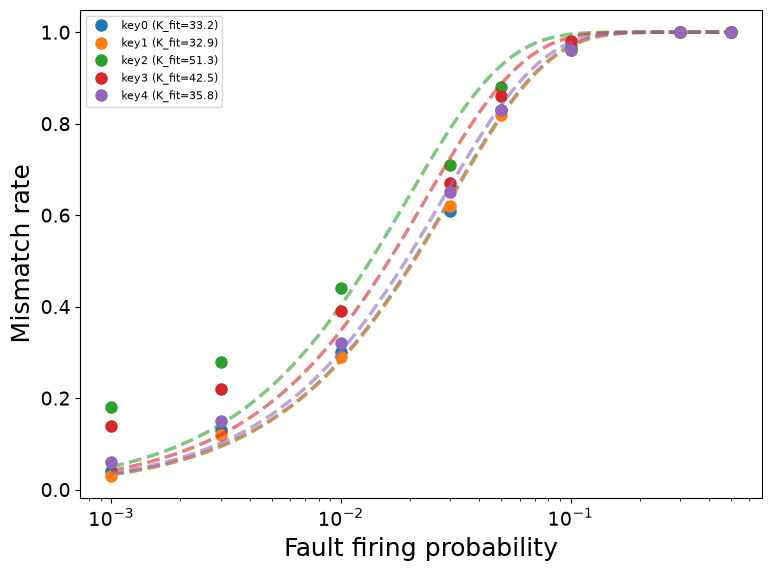

In [7]:
# --- Plot: observed points + fitted curve, per key ---
fig, ax = plt.subplots(figsize=(8, 6))
for key_idx in sorted(reconciliation_clean["key_index"].unique()):
    sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
    probs = sub.groupby("reconciliation_prob")["mismatch"].mean()
    K_fit = df_fit.loc[df_fit["key_index"] == key_idx, "K_fit"].values[0]
    if np.isnan(K_fit):
        continue

    line = ax.plot(probs.index, probs.values, "o", label=f"key{key_idx} (K_fit={K_fit:.1f})")[0]
    p_smooth = np.logspace(np.log10(probs.index.min()), np.log10(probs.index.max()), 100)
    ax.plot(p_smooth, model(p_smooth, K_fit), "--", alpha=0.6, color=line.get_color())

ax.set_xscale("log")
ax.set_xlabel("Fault firing probability")
ax.set_ylabel("Mismatch rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_reconciliation_empirical_fit.png"), dpi=150)
plt.show()

In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def model_with_baseline(p, b, c):
    return 1 - (1 - b) * (1 - p) ** c

results = []
for key_idx in sorted(reconciliation_clean["key_index"].unique()):
    sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]

    # c is FIXED to this key's actual measured total_corrections -- not fit, not theoretical
    c_fixed = sub["total_corrections"].mean()

    probs = sub.groupby("reconciliation_prob")["mismatch"].mean()
    p_vals = probs.index.values
    mismatch_vals = probs.values

    def model_fixed_c(p, b):
        return model_with_baseline(p, b, c_fixed)

    try:
        b_fit, b_cov = curve_fit(model_fixed_c, p_vals, mismatch_vals, p0=[0.05], bounds=(0, 1))
        b_fit = b_fit[0]
        b_err = np.sqrt(b_cov[0, 0])
    except RuntimeError as e:
        print(f"key{key_idx}: fit failed ({e})")
        b_fit, b_err = np.nan, np.nan

    results.append({
        "key_index": key_idx,
        "c_fixed (measured total_corrections)": c_fixed,
        "b_fit (baseline error rate)": b_fit,
        "b_fit_stderr": b_err,
    })

df_baseline_fit = pd.DataFrame(results)
print(df_baseline_fit.to_string(index=False))

 key_index  c_fixed (measured total_corrections)  b_fit (baseline error rate)  b_fit_stderr
         0                              32.79625                 1.992909e-02      0.009553
         1                              34.86875                 3.906122e-07      0.011002
         2                              32.50125                 1.925303e-01      0.013850
         3                              31.96000                 1.353539e-01      0.009955
         4                              33.42375                 4.359409e-02      0.006075


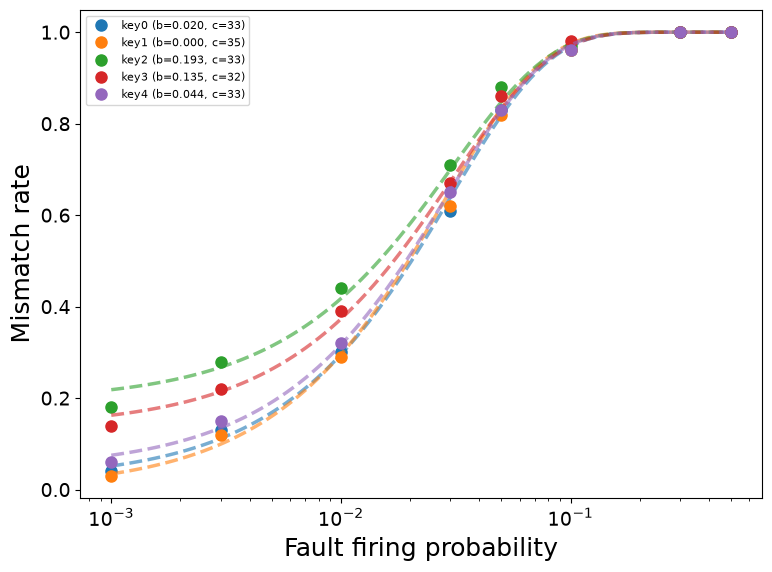

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for key_idx in sorted(reconciliation_clean["key_index"].unique()):
    sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
    probs = sub.groupby("reconciliation_prob")["mismatch"].mean()
    row = df_baseline_fit[df_baseline_fit["key_index"] == key_idx].iloc[0]
    c_fixed, b_fit = row["c_fixed (measured total_corrections)"], row["b_fit (baseline error rate)"]
    if np.isnan(b_fit):
        continue

    line = ax.plot(probs.index, probs.values, "o", label=f"key{key_idx} (b={b_fit:.3f}, c={c_fixed:.0f})")[0]
    p_smooth = np.logspace(np.log10(probs.index.min()), np.log10(probs.index.max()), 100)
    ax.plot(p_smooth, model_with_baseline(p_smooth, b_fit, c_fixed), "--", alpha=0.6, color=line.get_color())

ax.set_xscale("log")
ax.set_xlabel("Fault firing probability")
ax.set_ylabel("Mismatch rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_reconciliation_baseline_fit.png"), dpi=150)
plt.show()

In [10]:
reconciliation_clean["n_fired"] = reconciliation_clean["faults_fired"].apply(
    lambda s: eval(s).get("reconciliation_state", 0) if isinstance(s, str) else 0
)
zero_fired = reconciliation_clean[reconciliation_clean["n_fired"] == 0]
print(zero_fired.groupby("key_index")["mismatch"].agg(["mean", "count"]))

               mean  count
key_index                 
0          0.015723    318
1          0.000000    316
2          0.203762    319
3          0.138365    318
4          0.041139    316


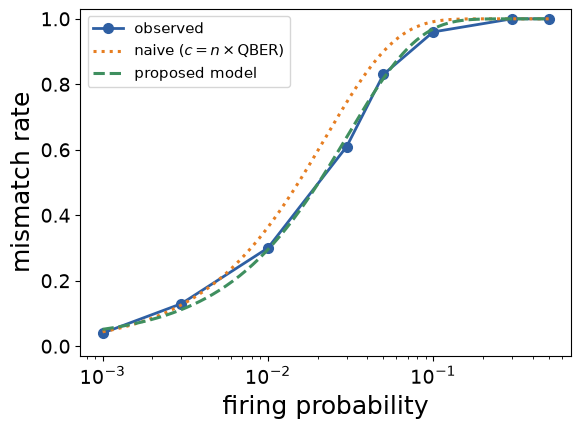

key0: c=32.8, c_naive=44.9, ratio=0.73, b=0.0199


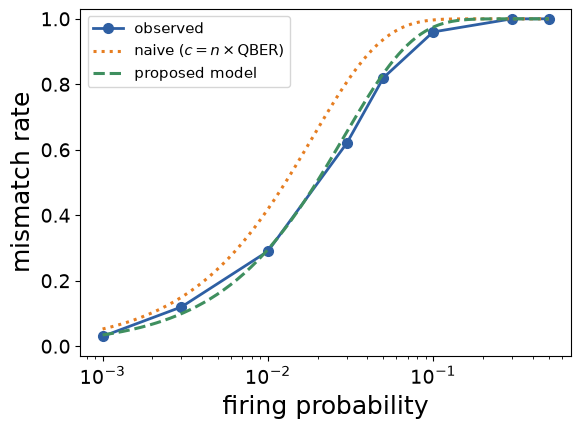

key1: c=34.9, c_naive=54.0, ratio=0.65, b=0.0000


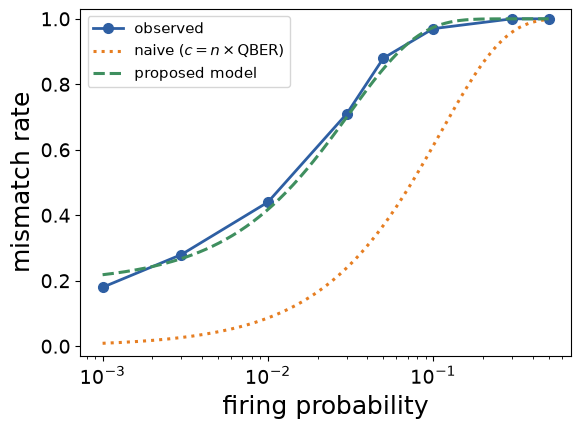

key2: c=32.5, c_naive=9.0, ratio=3.62, b=0.1925


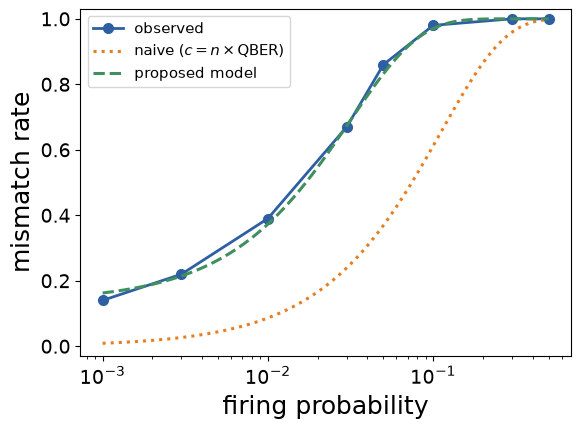

key3: c=32.0, c_naive=9.0, ratio=3.56, b=0.1354


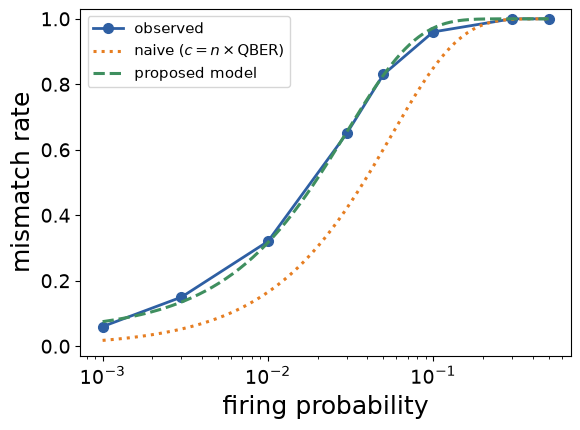

key4: c=33.4, c_naive=18.0, ratio=1.86, b=0.0436


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reconciliation_fit(key_idx, reconciliation_clean, key_pairs_df, df_baseline_fit, save=True):
    sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
    c_fixed = sub["total_corrections"].mean()
    krow = key_pairs_df.iloc[key_idx]
    c_naive = krow["n_bits"] * krow["qber"]
    b_fit = df_baseline_fit.loc[df_baseline_fit["key_index"] == key_idx, "b_fit (baseline error rate)"].values[0]

    probs = sub.groupby("reconciliation_prob")["mismatch"].mean()
    p_vals, obs = probs.index.values, probs.values

    p_smooth = np.logspace(np.log10(p_vals.min()), np.log10(p_vals.max()), 200)
    naive_curve = 1 - (1 - p_smooth) ** c_naive
    proposed_curve = 1 - (1 - b_fit) * (1 - p_smooth) ** c_fixed

    plt.rcParams.update({"font.size": 13})
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(p_vals, obs, "o-", color="#2E5FA3", label="observed", markersize=7, linewidth=2)
    ax.plot(p_smooth, naive_curve, ":", color="#E67E22", label=r"naive ($c=n\times$QBER)", linewidth=2.2)
    ax.plot(p_smooth, proposed_curve, "--", color="#3F8F5F", label="proposed model", linewidth=2.2)

    ax.set_xscale("log")
    ax.set_xlabel("firing probability")
    ax.set_ylabel("mismatch rate")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="upper left", fontsize=10.5)
    fig.tight_layout()
    if save:
        fig.savefig(str(RESULTS / f"fig_reconciliation_fit_key{key_idx}.png"), dpi=200)
    plt.show()
    return c_fixed, c_naive, b_fit

# Generate for every key -- pick the clearest one (largest naive/proposed gap) for the paper
for key_idx in sorted(reconciliation_clean["key_index"].unique()):
    c_fixed, c_naive, b_fit = plot_reconciliation_fit(key_idx, reconciliation_clean, key_pairs_df, df_baseline_fit)
    print(f"key{key_idx}: c={c_fixed:.1f}, c_naive={c_naive:.1f}, ratio={c_fixed/c_naive:.2f}, b={b_fit:.4f}")

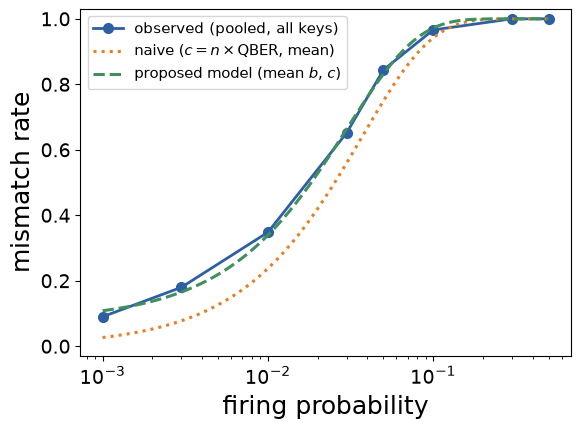

mean c (measured) = 33.11
mean c_naive (n*QBER) = 26.96
mean ratio c/c_naive = 2.08
mean b (baseline error) = 0.0783
   key_index         c    c_naive             b
0          0  32.79625  44.923077  1.992909e-02
1          1  34.86875  53.968338  3.906122e-07
2          2  32.50125   8.983957  1.925303e-01
3          3  31.96000   8.981675  1.353539e-01
4          4  33.42375  17.953247  4.359409e-02


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reconciliation_fit_pooled(reconciliation_clean, key_pairs_df, df_baseline_fit, save=True):
    """Pooled across all keys: average observed mismatch rate at each firing
    probability, plotted against the naive and proposed model curves using
    each key's own (c, c_naive, b) -- then averaged, not fit fresh on pooled data."""

    # Per-key model params, needed to build an average model curve
    per_key = []
    for key_idx in sorted(reconciliation_clean["key_index"].unique()):
        sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
        c_fixed = sub["total_corrections"].mean()
        krow = key_pairs_df.iloc[key_idx]
        c_naive = krow["n_bits"] * krow["qber"]
        b_fit = df_baseline_fit.loc[df_baseline_fit["key_index"] == key_idx, "b_fit (baseline error rate)"].values[0]
        per_key.append({"key_index": key_idx, "c": c_fixed, "c_naive": c_naive, "b": b_fit})
    per_key_df = pd.DataFrame(per_key)

    mean_c = per_key_df["c"].mean()
    mean_c_naive = per_key_df["c_naive"].mean()
    mean_b = per_key_df["b"].mean()

    # Pooled observed: average mismatch rate across ALL keys at each firing probability
    pooled_obs = reconciliation_clean.groupby("reconciliation_prob")["mismatch"].mean()
    p_vals, obs = pooled_obs.index.values, pooled_obs.values

    p_smooth = np.logspace(np.log10(p_vals.min()), np.log10(p_vals.max()), 200)
    naive_curve = 1 - (1 - p_smooth) ** mean_c_naive
    proposed_curve = 1 - (1 - mean_b) * (1 - p_smooth) ** mean_c

    plt.rcParams.update({"font.size": 13})
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(p_vals, obs, "o-", color="#2E5FA3", label="observed (pooled, all keys)", markersize=7, linewidth=2)
    ax.plot(p_smooth, naive_curve, ":", color="#E67E22", label=r"naive ($c=n\times$QBER, mean)", linewidth=2.2)
    ax.plot(p_smooth, proposed_curve, "--", color="#3F8F5F", label="proposed model (mean $b$, $c$)", linewidth=2.2)

    ax.set_xscale("log")
    ax.set_xlabel("firing probability")
    ax.set_ylabel("mismatch rate")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="upper left", fontsize=10.5)
    fig.tight_layout()
    if save:
        fig.savefig(str(RESULTS / "fig_reconciliation_fit_pooled.png"), dpi=200)
    plt.show()

    print(f"mean c (measured) = {mean_c:.2f}")
    print(f"mean c_naive (n*QBER) = {mean_c_naive:.2f}")
    print(f"mean ratio c/c_naive = {(per_key_df['c']/per_key_df['c_naive']).mean():.2f}")
    print(f"mean b (baseline error) = {mean_b:.4f}")
    return per_key_df

per_key_df = plot_reconciliation_fit_pooled(reconciliation_clean, key_pairs_df, df_baseline_fit)
print(per_key_df)

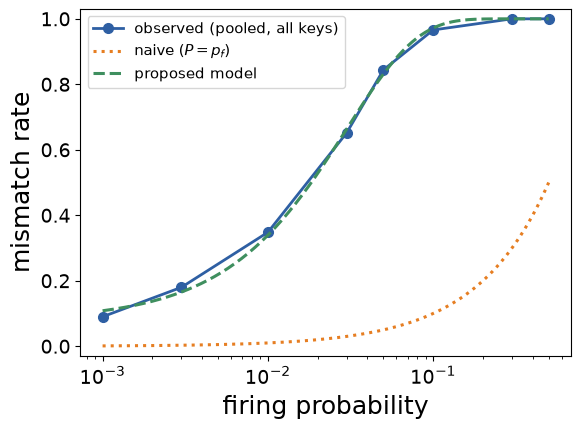

mean c (measured) = 33.11, mean b = 0.0783
   key_index         c             b
0          0  32.79625  1.992909e-02
1          1  34.86875  3.906122e-07
2          2  32.50125  1.925303e-01
3          3  31.96000  1.353539e-01
4          4  33.42375  4.359409e-02


In [13]:
def plot_reconciliation_fit_pooled(reconciliation_clean, key_pairs_df, df_baseline_fit, save=True):
    per_key = []
    for key_idx in sorted(reconciliation_clean["key_index"].unique()):
        sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
        c_fixed = sub["total_corrections"].mean()
        b_fit = df_baseline_fit.loc[df_baseline_fit["key_index"] == key_idx, "b_fit (baseline error rate)"].values[0]
        per_key.append({"key_index": key_idx, "c": c_fixed, "b": b_fit})
    per_key_df = pd.DataFrame(per_key)

    mean_c = per_key_df["c"].mean()
    mean_b = per_key_df["b"].mean()

    pooled_obs = reconciliation_clean.groupby("reconciliation_prob")["mismatch"].mean()
    p_vals, obs = pooled_obs.index.values, pooled_obs.values

    p_smooth = np.logspace(np.log10(p_vals.min()), np.log10(p_vals.max()), 200)
    naive_curve = p_smooth  # P(D) = p_f -- one firing assumed to directly cause one mismatch
    proposed_curve = 1 - (1 - mean_b) * (1 - p_smooth) ** mean_c

    plt.rcParams.update({"font.size": 13})
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(p_vals, obs, "o-", color="#2E5FA3", label="observed (pooled, all keys)", markersize=7, linewidth=2)
    ax.plot(p_smooth, naive_curve, ":", color="#E67E22", label=r"naive ($P=p_f$)", linewidth=2.2)
    ax.plot(p_smooth, proposed_curve, "--", color="#3F8F5F", label="proposed model", linewidth=2.2)

    ax.set_xscale("log")
    ax.set_xlabel("firing probability")
    ax.set_ylabel("mismatch rate")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="upper left", fontsize=10.5)
    fig.tight_layout()
    if save:
        fig.savefig(str(RESULTS / "fig_reconciliation_fit_pooled.png"), dpi=200)
    plt.show()

    print(f"mean c (measured) = {mean_c:.2f}, mean b = {mean_b:.4f}")
    return per_key_df

per_key_df = plot_reconciliation_fit_pooled(reconciliation_clean, key_pairs_df, df_baseline_fit)
print(per_key_df)

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

def chi_square_reconciliation_baseline_model(reconciliation_clean, key_pairs_df, df_baseline_fit):
    chi2_stat, dof = 0.0, 0
    rows = []

    for key_idx in sorted(reconciliation_clean["key_index"].unique()):
        sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
        c_fixed = sub["total_corrections"].mean()
        b_fit = df_baseline_fit.loc[df_baseline_fit["key_index"] == key_idx, "b_fit (baseline error rate)"].values[0]

        key_chi2, key_dof = 0.0, 0
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n_trials = len(trials)
            observed_mismatch = trials["mismatch"].sum()

            predicted_p = 1 - (1 - b_fit) * (1 - prob) ** c_fixed
            predicted_p = min(max(predicted_p, 1e-6), 1 - 1e-6)

            expected_mismatch = n_trials * predicted_p
            expected_match = n_trials * (1 - predicted_p)
            observed_match = n_trials - observed_mismatch

            key_chi2 += (observed_mismatch - expected_mismatch) ** 2 / expected_mismatch
            key_chi2 += (observed_match - expected_match) ** 2 / expected_match
            key_dof += 1

        p_value = 1 - chi2.cdf(key_chi2, key_dof)
        rows.append({"key_index": key_idx, "c": c_fixed, "b": b_fit,
                      "chi2": key_chi2, "dof": key_dof, "p_value": p_value})
        chi2_stat += key_chi2
        dof += key_dof

    per_key_df = pd.DataFrame(rows)
    overall_p = 1 - chi2.cdf(chi2_stat, dof)

    print(per_key_df.to_string(index=False))
    print(f"\nOverall (pooled across keys): chi2={chi2_stat:.2f}, dof={dof}, p={overall_p:.4f}")
    print("NOT rejected" if overall_p > 0.05 else "REJECTED")
    return per_key_df, chi2_stat, dof, overall_p

per_key_chi2, chi2_stat, dof, overall_p = chi_square_reconciliation_baseline_model(
    reconciliation_clean, key_pairs_df, df_baseline_fit
)

 key_index        c            b     chi2  dof  p_value
         0 32.79625 1.992909e-02 1.356261    8 0.994845
         1 34.86875 3.906122e-07 2.042651    8 0.979676
         2 32.50125 1.925303e-01 2.064671    8 0.978965
         3 31.96000 1.353539e-01 1.410928    8 0.994090
         4 33.42375 4.359409e-02 1.039658    8 0.997985

Overall (pooled across keys): chi2=7.91, dof=40, p=1.0000
NOT rejected


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import chi2, linregress

def leave_one_key_out_c_generalization(reconciliation_clean, key_pairs_df):
    """Leave-one-key-out: fit c ~ a + slope*QBER on 4 keys, predict c (and
    therefore P(D)) for the held-out key's QBER, compare against its
    actually observed mismatch rates. No baseline term b here -- this test
    is specifically about whether c's relationship to QBER generalizes,
    independent of the separate baseline-error question."""

    # Per-key (QBER, measured c) points -- the regression dataset
    per_key = []
    for key_idx in sorted(reconciliation_clean["key_index"].unique()):
        sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
        c_measured = sub["total_corrections"].mean()
        qber = key_pairs_df.iloc[key_idx]["qber"]
        per_key.append({"key_index": key_idx, "qber": qber, "c_measured": c_measured})
    per_key_df = pd.DataFrame(per_key)

    all_rows = []
    fold_summaries = []

    for held_out_idx in per_key_df["key_index"]:
        train = per_key_df[per_key_df["key_index"] != held_out_idx]
        test_row = per_key_df[per_key_df["key_index"] == held_out_idx].iloc[0]

        # Fit c ~ a + slope*QBER on the other 4 keys
        fit = linregress(train["qber"], train["c_measured"])
        c_pred = fit.intercept + fit.slope * test_row["qber"]

        fold_summaries.append({
            "held_out_key": held_out_idx, "intercept": fit.intercept, "slope": fit.slope,
            "c_measured": test_row["c_measured"], "c_pred": c_pred,
        })

        # Predict mismatch rate at each firing probability for the held-out key,
        # using c_pred instead of the directly measured c
        sub = reconciliation_clean[reconciliation_clean["key_index"] == held_out_idx]
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n_trials = len(trials)
            observed_rate = trials["mismatch"].mean()
            predicted_rate = 1 - (1 - prob) ** c_pred

            all_rows.append({
                "held_out_key": held_out_idx, "prob": prob, "n_trials": n_trials,
                "observed_rate": observed_rate, "predicted_rate": predicted_rate,
                "abs_error": abs(observed_rate - predicted_rate),
            })

    results_df = pd.DataFrame(all_rows)
    fold_df = pd.DataFrame(fold_summaries)

    mae = results_df["abs_error"].mean()

    # Chi-square across all held-out predictions, pooled
    chi2_stat, dof = 0.0, 0
    for _, row in results_df.iterrows():
        n = row["n_trials"]
        p_pred = min(max(row["predicted_rate"], 1e-6), 1 - 1e-6)
        observed_mismatch = row["observed_rate"] * n
        expected_mismatch = n * p_pred
        expected_match = n * (1 - p_pred)
        observed_match = n - observed_mismatch
        chi2_stat += (observed_mismatch - expected_mismatch) ** 2 / expected_mismatch
        chi2_stat += (observed_match - expected_match) ** 2 / expected_match
        dof += 1

    p_value = 1 - chi2.cdf(chi2_stat, dof)

    print("Per-fold regression (train on 4 keys, predict held-out):")
    print(fold_df.to_string(index=False))
    print(f"\nMean absolute error (predicted vs. observed mismatch rate): {mae:.4f}")
    print(f"Chi-square (pooled, held-out predictions): chi2={chi2_stat:.2f}, dof={dof}, p={p_value:.4f}")
    print("NOT rejected -- generalizes" if p_value > 0.05 else "REJECTED")

    return results_df, fold_df, mae, chi2_stat, dof, p_value

results_df, fold_df, mae, chi2_stat, dof, p_value = leave_one_key_out_c_generalization(
    reconciliation_clean, key_pairs_df
)

Per-fold regression (train on 4 keys, predict held-out):
 held_out_key  intercept      slope  c_measured    c_pred
            0  31.923741 192.221081    32.79625 34.388114
            1  32.400798  46.254836    34.86875 33.133065
            2  31.939588 145.084527    32.50125 32.327514
            3  32.346086 115.159515    31.96000 32.647551
            4  31.716467 154.975863    33.42375 32.521536

Mean absolute error (predicted vs. observed mismatch rate): 0.0359
Chi-square (pooled, held-out predictions): chi2=209.15, dof=40, p=0.0000
REJECTED


In [16]:
def leave_one_key_out_c_generalization_with_baseline(reconciliation_clean, key_pairs_df, df_baseline_fit):
    per_key = []
    for key_idx in sorted(reconciliation_clean["key_index"].unique()):
        sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
        c_measured = sub["total_corrections"].mean()
        qber = key_pairs_df.iloc[key_idx]["qber"]
        b = df_baseline_fit.loc[df_baseline_fit["key_index"] == key_idx, "b_fit (baseline error rate)"].values[0]
        per_key.append({"key_index": key_idx, "qber": qber, "c_measured": c_measured, "b": b})
    per_key_df = pd.DataFrame(per_key)

    all_rows, fold_summaries = [], []
    for held_out_idx in per_key_df["key_index"]:
        train = per_key_df[per_key_df["key_index"] != held_out_idx]
        test_row = per_key_df[per_key_df["key_index"] == held_out_idx].iloc[0]

        fit = linregress(train["qber"], train["c_measured"])
        c_pred = fit.intercept + fit.slope * test_row["qber"]
        b_held_out = test_row["b"]  # use this key's own already-fit b, unchanged

        fold_summaries.append({"held_out_key": held_out_idx, "c_measured": test_row["c_measured"],
                                  "c_pred": c_pred, "b": b_held_out})

        sub = reconciliation_clean[reconciliation_clean["key_index"] == held_out_idx]
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n_trials = len(trials)
            observed_rate = trials["mismatch"].mean()
            predicted_rate = 1 - (1 - b_held_out) * (1 - prob) ** c_pred
            all_rows.append({"held_out_key": held_out_idx, "prob": prob, "n_trials": n_trials,
                              "observed_rate": observed_rate, "predicted_rate": predicted_rate,
                              "abs_error": abs(observed_rate - predicted_rate)})

    results_df = pd.DataFrame(all_rows)
    mae = results_df["abs_error"].mean()

    chi2_stat, dof = 0.0, 0
    for _, row in results_df.iterrows():
        n = row["n_trials"]
        p_pred = min(max(row["predicted_rate"], 1e-6), 1 - 1e-6)
        observed_mismatch = row["observed_rate"] * n
        expected_mismatch, expected_match = n * p_pred, n * (1 - p_pred)
        observed_match = n - observed_mismatch
        chi2_stat += (observed_mismatch - expected_mismatch) ** 2 / expected_mismatch
        chi2_stat += (observed_match - expected_match) ** 2 / expected_match
        dof += 1
    p_value = 1 - chi2.cdf(chi2_stat, dof)

    print(pd.DataFrame(fold_summaries).to_string(index=False))
    print(f"\nMAE: {mae:.4f}")
    print(f"chi2={chi2_stat:.2f}, dof={dof}, p={p_value:.4f}")
    print("NOT rejected" if p_value > 0.05 else "REJECTED")
    return results_df, mae, chi2_stat, dof, p_value

leave_one_key_out_c_generalization_with_baseline(reconciliation_clean, key_pairs_df, df_baseline_fit)

 held_out_key  c_measured    c_pred            b
            0    32.79625 34.388114 1.992909e-02
            1    34.86875 33.133065 3.906122e-07
            2    32.50125 32.327514 1.925303e-01
            3    31.96000 32.647551 1.353539e-01
            4    33.42375 32.521536 4.359409e-02

MAE: 0.0107
chi2=7.65, dof=40, p=1.0000
NOT rejected


(    held_out_key   prob  n_trials  observed_rate  predicted_rate     abs_error
 0              0  0.001       100           0.04        0.053075  1.307527e-02
 1              0  0.003       100           0.13        0.116134  1.386605e-02
 2              0  0.010       100           0.30        0.306319  6.318562e-03
 3              0  0.030       100           0.61        0.656155  4.615526e-02
 4              0  0.050       100           0.83        0.832037  2.036738e-03
 5              0  0.100       100           0.96        0.973834  1.383362e-02
 6              0  0.300       100           1.00        0.999995  4.618184e-06
 7              0  0.500       100           1.00        1.000000  4.359169e-11
 8              1  0.001       100           0.03        0.032607  2.606592e-03
 9              1  0.003       100           0.12        0.094754  2.524561e-02
 10             1  0.010       100           0.29        0.283229  6.771041e-03
 11             1  0.030       100      